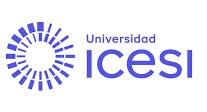


#Universidad ICESI

NLP - PROCESAMIENTO DE LENGUAJE NATURAL -
Profesor : Luis Ferro Diez
Cuaderno de normalizacion y patrones  en NLP - 3er semestre de 2026.
Presentado por : Edwin Perez -Rubén Darío Sabogal - Cristian Camilo Quebrada
https://colab.research.google.com/drive/1l1qbYk1mmT3msszhJf4ah-M26ChnSzO_#scrollTo=XJQ6G8YsmZUt

------------------------------------------------------

# Caso  — Cybersecurity Word2Vec Laboratory
## NLP aplicado a gestión de vulnerabilidades y EMCALI Cyber 2.0

**Objetivo:** construir un corpus de ciberseguridad, aprender embeddings y comparar **Word2Vec-CBOW, Word2Vec-Skip-Gram, FastText, BERT y Sentence-BERT**.

### Pregunta de investigación
**¿Qué representación semántica captura mejor las relaciones entre conceptos de ciberseguridad y cuál resulta más útil para recuperar vulnerabilidades similares en una plataforma como EMCALI Cyber 2.0?**

### Fuentes del corpus
- NVD / descripciones CVE.
- CISA KEV.
- MITRE ATT&CK Enterprise.
- CWE.
- Glosario técnico controlado del laboratorio.
- Documentación propia opcional (`.txt`/`.md`) si su uso está autorizado.

### Conceptos que estudiaremos
`CVE`, `vulnerability`, `exploit`, `RCE`, `malware`, `ransomware`, `credential`, `privilege`, `patch`, `remediation`, `CVSS`, `EPSS`, `KEV`.

> El laboratorio es defensivo: analiza texto para búsqueda, clasificación semántica, priorización y remediación. No construye exploits ni ejecuta técnicas de ataque.

## 1. Cómo explicarlo en clase

La historia completa cabe en siete pasos:

1. **Reunimos documentos** de ciberseguridad.
2. **Limpiamos el texto** sin destruir CVE/CWE/acrónimos.
3. **Entrenamos Word2Vec** con CBOW y Skip-Gram.
4. **Probamos FastText** para palabras no vistas.
5. **Usamos BERT** para contexto.
6. **Usamos Sentence-BERT** para comparar frases/documentos.
7. **Construimos una búsqueda semántica** reutilizable en EMCALI Cyber 2.0.

La idea fundamental es sencilla: **textos parecidos deberían producir vectores cercanos**.

### Explicación detallada del Paso 1: Reunir Documentos de Ciberseguridad

Este primer paso es crucial para la construcción de un corpus robusto y representativo del dominio de ciberseguridad. Implica la recopilación de diversas fuentes de información que contienen terminología, conceptos y contextos relevantes para la gestión de vulnerabilidades y la ciberseguridad en general.

Las fuentes de datos típicas incluyen:

*   **Bases de Datos de Vulnerabilidades (NVD/CVE):** Descripciones estandarizadas de vulnerabilidades de seguridad y exposiciones. Son fundamentales para entender el lenguaje técnico asociado a fallos de seguridad.
*   **Listas de Vulnerabilidades Explotadas Conocidas (CISA KEV):** Proporcionan información sobre vulnerabilidades que han sido activamente explotadas, lo cual es vital para priorizar esfuerzos de remediación.
*   **Marcos de Conocimiento de Adversarios (MITRE ATT&CK):** Describen tácticas y técnicas empleadas por adversarios, aportando un contexto sobre cómo se realizan los ataques y cómo se defienden los sistemas.
*   **Enumeración de Debilidades Comunes (CWE):** Un catálogo de tipos de debilidades de seguridad en el diseño, desarrollo y arquitectura de software.
*   **Glosarios Técnicos y Documentación Interna:** Textos específicos que pueden contener terminología propietaria o de uso común dentro de una organización, asegurando que el modelo capture un léxico más completo y relevante para el entorno específico.

## 2. Qué aporta frente a un ejemplo básico

El cuaderno incluye:
- EDA del corpus.
- Normalización específica de ciberseguridad.
- CBOW vs Skip-Gram.
- FastText y OOV.
- BERT contextual.
- Sentence-BERT.
- Mini-benchmark semántico.
- PCA y matrices de similitud.
- Análisis automático de hallazgos.
- Demo de recuperación de CVE/KEV/CWE.
- Propuesta de integración con RAG/EMCALI Cyber 2.0.

### Explicación detallada del Paso 2: Limpieza del Texto sin destruir CVE/CWE/acrónimos

Este paso se centra en la pre-procesamiento del texto para prepararlo para los modelos de incrustación de palabras (embeddings), pero con una consideración especial para la naturaleza del dominio de ciberseguridad. A diferencia de la limpieza de texto genérica, donde a menudo se eliminan números, símbolos y se reducen las palabras a sus raíces (stemming/lemmatization), aquí se adopta un enfoque más conservador.

Los objetivos clave de esta fase son:

*   **Preservar Identificadores:** Es fundamental mantener intactos los identificadores como `CVE-XXXX-XXXX`, `CWE-XXX` y `TXXXX` (de MITRE ATT&CK), ya que son piezas de información crítica y no deben ser fragmentados o modificados. Estos actúan como tokens únicos y significativos.
*   **Manejo de Acrónimos y Términos Técnicos:** Los acrónimos como `RCE`, `CVSS`, `EPSS`, `KEV`, etc., son esenciales en ciberseguridad. Se deben procesar de manera que no se pierda su significado o se confundan con palabras comunes. En algunos casos, se pueden normalizar para asegurar una representación consistente (ej., `Remote Code Execution` a `remote_code_execution`).
*   **Conversión a minúsculas:** Generalmente, se convierte todo el texto a minúsculas para reducir la dimensionalidad del vocabulario y tratar palabras como 'Vulnerability' y 'vulnerability' como el mismo token.
*   **Eliminación de Ruido:** Se eliminan caracteres especiales, puntuación y números que no forman parte de identificadores o términos técnicos, así como URLs o direcciones IP, que pueden ser ruido para el aprendizaje semántico.
*   **Tokenización:** El texto se divide en unidades significativas (palabras o tokens) que serán las entradas para los modelos de lenguaje. La tokenización debe ser cuidadosa para no romper los identificadores preservados.

La estrategia de limpieza es un equilibrio entre la reducción de ruido y la retención de información clave específica del dominio, asegurando que los modelos posteriores puedan aprender representaciones semánticas precisas para los conceptos de ciberseguridad.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Esta celda vacía está disponible para cualquier prueba o código auxiliar que necesites.
# Si deseas documentar el cuaderno completo, se recomienda añadir celdas de texto (Markdown)
# entre las secciones para proporcionar explicaciones detalladas de cada punto.

## 3. Preparación de Google Colab

Recomendado: **Entorno de ejecución → Cambiar tipo de entorno → T4 GPU**.

Word2Vec/FastText funcionan bien en CPU. BERT/Sentence-BERT aprovechan GPU.

### Explicación detallada del Paso 3: Entrenar Word2Vec (CBOW y Skip-Gram)

El tercer paso implica el entrenamiento de modelos Word2Vec, tanto en su arquitectura Continuous Bag-of-Words (CBOW) como en Skip-Gram. Estos modelos son fundamentales para capturar las relaciones semánticas entre palabras en nuestro corpus de ciberseguridad, transformándolas en vectores densos (embeddings).

**¿Cómo funcionan?**

*   **CBOW (Continuous Bag-of-Words):** Este modelo predice una palabra objetivo a partir de su contexto circundante (un "bag of words" sin considerar el orden). Es decir, toma las palabras que rodean a la palabra central y trata de adivinar cuál es esa palabra central. Es generalmente más rápido de entrenar y funciona bien con corpus grandes.

*   **Skip-Gram:** A diferencia de CBOW, Skip-Gram predice las palabras del contexto (palabras circundantes) dada una palabra central. Es más lento de entrenar, pero suele ser más efectivo para palabras raras o poco frecuentes, ya que intenta predecir múltiples palabras de contexto para cada palabra central.

**Consideraciones en nuestro laboratorio:**

*   **Tamaño del Corpus:** Aunque nuestro corpus es acotado para un entorno de laboratorio, Word2Vec puede aprender relaciones significativas incluso con volúmenes moderados de texto, especialmente si el vocabulario es especializado.
*   **Parámetros:** Se configurarán parámetros como el tamaño del vector (`vector_size`), la ventana de contexto (`window`), el número mínimo de ocurrencias de una palabra (`min_count`), y el número de épocas (`epochs`) para optimizar el aprendizaje de las representaciones.
*   **Evaluación:** La calidad de los embeddings se evaluará observando la similitud coseno entre palabras relacionadas y no relacionadas, y mediante visualizaciones 2D utilizando técnicas de reducción de dimensionalidad como PCA.

In [ ]:
# ============================================================
# CASO 2 - CYBERSECURITY WORD2VEC LABORATORY
# Preparación del entorno Google Colab
# ============================================================

# IMPORTANTE:
# No actualizamos NumPy, Pandas, PyTorch ni Requests.
# Google Colab ya instala versiones compatibles de estas librerías.

%pip install -q \
    "gensim==4.4.0" \
    "transformers" \
    "sentence-transformers"

In [ ]:
# ============================================================
# IMPORTS GENERALES
# Cybersecurity Word2Vec Laboratory
# ============================================================

import os
import re
import json
import math
import random
import warnings

from pathlib import Path
from collections import Counter
from datetime import datetime, timedelta, timezone
from urllib.parse import urlencode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch

from tqdm.auto import tqdm

from gensim.models import Word2Vec, FastText

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

print("✅ Imports generales cargados correctamente.")

✅ Imports generales cargados correctamente.


In [ ]:
!pip check

ipython 7.34.0 requires jedi, which is not installed.
google-colab 1.0.0 has requirement pandas==2.2.3, but you have pandas 3.0.5.
google-colab 1.0.0 has requirement requests==2.32.4, but you have requests 2.34.2.
cudf-cu12 26.2.1 has requirement pandas<2.4.0,>=2.0, but you have pandas 3.0.5.
numba 0.61.2 has requirement numpy<2.3,>=1.24, but you have numpy 2.5.3.
dask-cudf-cu12 26.2.1 has requirement pandas<2.4.0,>=2.0, but you have pandas 3.0.5.


In [ ]:
# ==========================================================
# PRUEBA DE SALUD DEL ENTORNO
# Cybersecurity Word2Vec Laboratory
# ==========================================================

import numpy as np
import pandas as pd
import requests
import torch
import gensim
import sklearn
import transformers
import sentence_transformers

from gensim.models import Word2Vec, FastText
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

print("=" * 65)
print("CYBERSECURITY NLP LAB - HEALTH CHECK")
print("=" * 65)

print("NumPy               :", np.__version__)
print("Pandas              :", pd.__version__)
print("Requests            :", requests.__version__)
print("Gensim              :", gensim.__version__)
print("Scikit-learn        :", sklearn.__version__)
print("Transformers        :", transformers.__version__)
print("SentenceTransformers:", sentence_transformers.__version__)
print("CUDA disponible     :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU                  :", torch.cuda.get_device_name(0))

print("=" * 65)
print("✅ Entorno NLP preparado.")

CYBERSECURITY NLP LAB - HEALTH CHECK
NumPy               : 2.5.3
Pandas              : 3.0.5
Requests            : 2.34.2
Gensim              : 4.4.0
Scikit-learn        : 1.9.0
Transformers        : 5.16.1
SentenceTransformers: 6.0.1
CUDA disponible     : True
GPU                  : Tesla T4
✅ Entorno NLP preparado.


In [ ]:
# Prueba mínima de Word2Vec

mini_corpus = [
    ["vulnerability", "exploit", "patch", "remediation"],
    ["cve", "vulnerability", "cvss", "severity"],
    ["exploit", "malware", "ransomware"],
    ["patch", "mitigation", "remediation"],
    ["credential", "privilege", "escalation"],
    ["kev", "exploit", "vulnerability"],
]

test_model = Word2Vec(
    sentences=mini_corpus,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    epochs=20,
    seed=42
)

print("✅ Word2Vec funciona.")
print("Tamaño vocabulario:", len(test_model.wv))
print("Vector vulnerability:", test_model.wv["vulnerability"][:5])

✅ Word2Vec funciona.
Tamaño vocabulario: 14
Vector vulnerability: [ 1.0397553e-02 -1.2216304e-02 -5.4445839e-03 -1.3313618e-03
 -8.8352244e-05]


## 4. Construcción del corpus

Cada registro tendrá `source`, `doc_id`, `title`, `text` y metadatos disponibles. Para facilitar la ejecución usamos muestras acotadas, no las bases completas.

### Explicación detallada del Paso 4: Probar FastText para Palabras no Vistas (OOV)

Después de Word2Vec, el siguiente paso es explorar **FastText**. FastText es una extensión de Word2Vec que aborda una limitación clave de este último: su incapacidad para manejar palabras fuera del vocabulario (Out-Of-Vocabulary, OOV) o palabras raras.

**¿Cómo funciona FastText?**

A diferencia de Word2Vec, que asigna un vector a cada palabra completa, FastText representa cada palabra como una "bolsa" de n-gramas de caracteres (subpalabras). Por ejemplo, si la palabra es "vulnerabilidad" y usamos n-gramas de longitud 3 a 6, FastText podría ver y aprender de subpalabras como `vul`, `uln`, `lner`, `nera`, `nerab`, `erabil`, etc. Además, se añade el vector de la palabra completa.

Cuando FastText encuentra una palabra que no vio durante el entrenamiento (OOV), no simplemente la ignora. En su lugar, puede construir una representación vectorial para esa palabra a partir de los n-gramas de caracteres que sí conoce. Esto es particularmente útil en dominios técnicos como la ciberseguridad, donde:

*   **Nuevas vulnerabilidades y productos:** Constantemente aparecen nuevos nombres de exploits, variantes de malware, o productos que no estaban en el corpus de entrenamiento.
*   **Errores tipográficos o variaciones:** Puede manejar mejor las ligeras variaciones o errores tipográficos.
*   **Palabras compuestas o modificadas:** Terminos como `ZeroDay`, `CVE-2023-XXXXX`, o nombres de herramientas específicas se benefician de esta capacidad.

**Consideraciones en nuestro laboratorio:**

*   **Parámetros:** Se configurarán los parámetros de los n-gramas de caracteres (`min_n` y `max_n`) para encontrar un balance óptimo entre la captura de información morfológica y el ruido.
*   **Evaluación de OOV:** Se probará FastText con palabras que deliberadamente no se encontraban en el vocabulario de entrenamiento (simulando OOV) y se comparará su capacidad para generar vectores significativos con Word2Vec, que devolvería un error o un vector nulo.

In [ ]:
NVD_DAYS=120
NVD_MAX_DOCS=500
KEV_MAX_DOCS=1000
ATTACK_MAX_DOCS=700
REQUEST_TIMEOUT=90

corpus_rows=[]
def add_document(source, doc_id, title, text, **metadata):
    if text is None: return
    text=re.sub(r'\s+', ' ', str(text)).strip()
    if len(text)<25: return
    row={'source':source,'doc_id':str(doc_id),'title':str(title),'text':text}
    row.update(metadata); corpus_rows.append(row)

### 4.1 CISA KEV

KEV es especialmente valioso para gestión de vulnerabilidades porque identifica vulnerabilidades con **explotación conocida**. Conservaremos descripción y acción requerida.

In [ ]:
CISA_KEV_URL='https://raw.githubusercontent.com/cisagov/kev-data/develop/known_exploited_vulnerabilities.json'

def load_kev(max_docs=KEV_MAX_DOCS):
    try:
        data=requests.get(CISA_KEV_URL, timeout=REQUEST_TIMEOUT).json()
        vulns=data.get('vulnerabilities',[])[:max_docs]
        for v in vulns:
            cve=v.get('cveID',''); name=v.get('vulnerabilityName','')
            text=(f"KEV known exploited vulnerability {cve}. {name}. "
                  f"{v.get('shortDescription','')}. Required remediation action: "
                  f"{v.get('requiredAction','')}. CWE {' '.join(v.get('cwes',[]) or [])}. "
                  f"Known ransomware campaign use: {v.get('knownRansomwareCampaignUse','')}.")
            add_document('CISA_KEV',cve,name,text,cve_id=cve,kev=1,
                         ransomware_use=v.get('knownRansomwareCampaignUse',''))
        print('KEV añadidos:',len(vulns),'| versión:',data.get('catalogVersion'))
    except Exception as e: print('KEV no disponible:',e)
load_kev()

KEV añadidos: 1000 | versión: 2026.09.04


### 4.2 NVD / CVE

Consultamos una ventana reciente de la API NVD 2.0. Si la API limita temporalmente las peticiones, el resto del laboratorio continúa funcionando.

In [ ]:
def extract_cvss(cve):
    metrics=cve.get('metrics',{})
    for name in ['cvssMetricV40','cvssMetricV31','cvssMetricV30','cvssMetricV2']:
        vals=metrics.get(name,[])
        if vals:
            d=vals[0].get('cvssData',{})
            return d.get('baseScore'), d.get('baseSeverity')
    return None,None

def extract_cwes(cve):
    out=[]
    for w in cve.get('weaknesses',[]):
        for d in w.get('description',[]):
            if str(d.get('value','')).startswith('CWE-'): out.append(d['value'])
    return sorted(set(out))

def load_nvd():
    end=datetime.now(timezone.utc); start=end-timedelta(days=NVD_DAYS)
    params={'pubStartDate':start.strftime('%Y-%m-%dT%H:%M:%S.000'),
            'pubEndDate':end.strftime('%Y-%m-%dT%H:%M:%S.000'),
            'resultsPerPage':NVD_MAX_DOCS,'startIndex':0}
    url='https://services.nvd.nist.gov/rest/json/cves/2.0?'+urlencode(params)
    try:
        r=requests.get(url,timeout=REQUEST_TIMEOUT,headers={'User-Agent':'academic-cybersecurity-nlp-lab/1.0'})
        r.raise_for_status(); data=r.json(); added=0
        for item in data.get('vulnerabilities',[])[:NVD_MAX_DOCS]:
            cve=item.get('cve',{}); cid=cve.get('id','')
            desc=[d.get('value','') for d in cve.get('descriptions',[]) if d.get('lang')=='en']
            if not desc: continue
            score,severity=extract_cvss(cve); cwes=extract_cwes(cve)
            text=f"CVE vulnerability {cid}. {desc[0]}. CVSS severity {severity}. CVSS score {score}. CWE {' '.join(cwes)}."
            add_document('NVD_CVE',cid,cid,text,cve_id=cid,kev=0,cvss_score=score,cvss_severity=severity)
            added+=1
        print('NVD añadidos:',added,'| ventana:',start.date(),'a',end.date())
    except Exception as e: print('NVD no disponible; continuamos:',e)
load_nvd()

NVD añadidos: 500 | ventana: 2026-05-10 a 2026-09-07


### 4.3 MITRE ATT&CK Enterprise

Usaremos ATT&CK Enterprise **19.1** y extraeremos técnicas (`attack-pattern`) y mitigaciones (`course-of-action`).

In [ ]:
ATTACK_VERSION='19.1'
ATTACK_URL=f'https://raw.githubusercontent.com/mitre-attack/attack-stix-data/master/enterprise-attack/enterprise-attack-{ATTACK_VERSION}.json'

def attack_id(obj):
    for r in obj.get('external_references',[]):
        if r.get('external_id'): return r['external_id']
    return obj.get('id','')

def clean_attack_text(t):
    t=re.sub(r'\[(.*?)\]\([^)]+\)',r'\1',str(t))
    t=re.sub(r'\(Citation:[^)]+\)',' ',t)
    return re.sub(r'\s+',' ',t).strip()

def load_attack():
    try:
        data=requests.get(ATTACK_URL,timeout=REQUEST_TIMEOUT).json()
        objs=[o for o in data.get('objects',[]) if o.get('type') in {'attack-pattern','course-of-action'}
              and not o.get('revoked',False) and not o.get('x_mitre_deprecated',False) and o.get('description')]
        objs=objs[:ATTACK_MAX_DOCS]
        for o in objs:
            oid=attack_id(o); name=o.get('name',''); typ=o.get('type','')
            prefix='MITRE ATTACK technique' if typ=='attack-pattern' else 'MITRE ATTACK mitigation remediation'
            add_document('MITRE_ATTACK',oid,name,f"{prefix} {oid}. {name}. {clean_attack_text(o['description'])}",attack_type=typ,kev=0)
        print('ATT&CK añadidos:',len(objs),'| versión:',ATTACK_VERSION)
    except Exception as e: print('ATT&CK no disponible:',e)
load_attack()

ATT&CK añadidos: 700 | versión: 19.1


### 4.4 CWE

Consultamos una selección de debilidades relevantes para inyección, memoria, autenticación, autorización, exposición, traversal, SSRF y privilegios.

In [ ]:
CWE_IDS=[20,22,77,78,79,89,94,119,125,200,269,287,306,352,416,434,476,502,787,862,863,918]

def flatten_strings(obj):
    if isinstance(obj,str): return [obj]
    if isinstance(obj,dict):
        out=[]
        for v in obj.values(): out+=flatten_strings(v)
        return out
    if isinstance(obj,list):
        out=[]
        for v in obj: out+=flatten_strings(v)
        return out
    return []

def load_cwe():
    added=0
    for cid in tqdm(CWE_IDS,desc='CWE'):
        try:
            data=requests.get(f'https://cwe-api.mitre.org/api/v1/cwe/weakness/{cid}',timeout=REQUEST_TIMEOUT).json()
            strings=[s for s in flatten_strings(data) if len(s)>=20]
            text=' '.join(strings[:25])
            if text:
                add_document('CWE',f'CWE-{cid}',f'CWE-{cid}',f'CWE weakness CWE-{cid}. {text}',kev=0); added+=1
        except Exception: pass
    print('CWE añadidos:',added)
load_cwe()

CWE:   0%|          | 0/22 [00:00<?, ?it/s]

CWE añadidos: 22


### 4.5 Glosario técnico controlado

EPSS y algunos acrónimos pueden aparecer poco en la muestra. Añadimos frases **redactadas para el laboratorio** para garantizar que los conceptos pedagógicos estén representados. Esto influye en Word2Vec y debe reportarse como `glossary seeding`.

In [ ]:
GLOSSARY={
'cve':'CVE identifies a specific published vulnerability. CVE records connect vulnerability descriptions with patching remediation CVSS and CWE information.',
'vulnerability':'Vulnerability management includes discovery assessment prioritization patch remediation and verification.',
'exploit':'Known exploitation of a vulnerability increases remediation attention in vulnerability management.',
'rce':'RCE means remote code execution. Remote code execution may allow arbitrary code execution on a remote system.',
'malware':'Malware is malicious software. Ransomware is a type of malware associated with operational impact.',
'ransomware':'Ransomware is malware. Known ransomware campaign use can increase vulnerability prioritization.',
'credential':'Credential security includes passwords tokens and authentication material. Credential theft and credential dumping can enable unauthorized access.',
'privilege':'Privilege escalation allows elevated privileges. Least privilege and remediation reduce privilege escalation risk.',
'patch':'A security patch corrects vulnerable software. Patch deployment remediation and verification are core vulnerability management activities.',
'remediation':'Remediation reduces vulnerability risk through patching mitigation configuration changes compensating controls or removal.',
'cvss':'CVSS describes technical vulnerability severity and should be combined with other prioritization signals.',
'epss':'EPSS estimates the probability that a published vulnerability will be exploited. EPSS can complement CVSS.',
'kev':'KEV means Known Exploited Vulnerabilities. A KEV flag indicates known exploitation and supports prioritization.'}
for key,text in GLOSSARY.items():
    for i in range(3): add_document('LAB_GLOSSARY',f'{key}-{i+1}',key,text,kev=0)
print('Glosario añadido:',len(GLOSSARY)*3)

Glosario añadido: 39


### 4.6 Documentos propios (opcional)

La celda siguiente permite incorporar `.txt` o `.md` autorizados. **No subas documentación corporativa sensible a un servicio externo si la política de la organización no lo permite.**

In [ ]:
# OPCIONAL EN COLAB:
# from google.colab import files
# uploaded=files.upload()
# for filename,raw in uploaded.items():
#     if filename.lower().endswith(('.txt','.md')):
#         add_document('USER_DOCUMENT',filename,filename,raw.decode('utf-8',errors='ignore'),kev=0)

## 5. DataFrame y EDA

### Explicación detallada del Paso 5: Usar BERT para Contexto

El paso 5 introduce los modelos basados en Transformers, específicamente **BERT (Bidirectional Encoder Representations from Transformers)**. A diferencia de Word2Vec y FastText, que generan un vector estático para cada palabra, BERT es un modelo contextual. Esto significa que la representación vectorial (embedding) de una palabra varía según el contexto en el que aparece dentro de una oración o frase.

**¿Cómo funciona BERT y por qué es importante?**

*   **Bidireccionalidad:** BERT fue pre-entrenado para comprender el contexto de una palabra basándose en todas las demás palabras de una oración, tanto las que le preceden como las que le siguen. Esto contrasta con modelos anteriores que procesaban el texto de forma unidireccional.
*   **Atención (Attention Mechanism):** Utiliza un mecanismo de atención que le permite ponderar la importancia de diferentes palabras en la oración al generar el embedding de una palabra específica. Esto es crucial para desambiguar palabras con múltiples significados (polisemia).
*   **Contextualización Semántica:** En el dominio de la ciberseguridad, esto es invaluable. Por ejemplo, la palabra "exploit" puede referirse a un "programa que aprovecha una vulnerabilidad" o "el acto de aprovechar una vulnerabilidad". BERT puede diferenciar estos matices basándose en el contexto circundante, generando embeddings distintos para cada uso.
*   **Subpalabras (Subword Tokenization):** BERT utiliza tokenización a nivel de subpalabras (como WordPiece), lo que le permite manejar palabras raras o compuestas de manera eficiente sin las limitaciones estrictas de OOV de Word2Vec.
*   **Transfer Learning:** BERT se entrena inicialmente en un corpus masivo de texto (por ejemplo, libros y Wikipedia) en una tarea de "rellenar huecos" (Masked Language Model) y "predicción de la siguiente oración". Esto le permite aprender una comprensión muy rica del lenguaje, que luego puede ser transferida y ajustada (fine-tuned) para tareas específicas.

**Consideraciones en nuestro laboratorio:**

*   Utilizaremos una versión pre-entrenada de BERT (`bert-base-uncased`) para generar embeddings de oraciones completas. No realizaremos fine-tuning, ya que el objetivo es ilustrar su capacidad contextual.
*   La generación de embeddings de oraciones a partir de BERT a menudo implica técnicas como el *mean pooling* (promediar los embeddings de los tokens de la oración) o utilizar el embedding del token `[CLS]`, que se entrena para representar la oración completa.
*   Se demostrará cómo la misma palabra ("exploit") puede tener representaciones vectoriales diferentes en función de la frase en la que se encuentre, algo que Word2Vec no puede hacer por sí mismo.

In [ ]:
corpus_df=pd.DataFrame(corpus_rows)
if corpus_df.empty: raise RuntimeError('No se construyó el corpus; revise la conexión.')
corpus_df['text']=corpus_df['text'].fillna('').astype(str)
corpus_df['n_chars']=corpus_df['text'].str.len()
corpus_df['n_words_raw']=corpus_df['text'].str.split().str.len()
print('Documentos:',len(corpus_df)); display(corpus_df.head())

Documentos: 2300


,source,doc_id,title,text,cve_id,kev,ransomware_use,cvss_score,cvss_severity,attack_type,n_chars,n_words_raw
0,CISA_KEV,CVE-2026-85046,Google Chromium V8 Type Confusion Vulnerability,KEV known exploited vulnerability CVE-2026-850...,CVE-2026-85046,1,Unknown,NaN,NaN,NaN,980,135
1,CISA_KEV,CVE-2026-59822,BerriAI LiteLLM Improper Authentication Vulner...,KEV known exploited vulnerability CVE-2026-598...,CVE-2026-59822,1,Unknown,NaN,NaN,NaN,907,119
2,CISA_KEV,CVE-2026-48710,Kludex Starlette HTTP Request/Response Smuggli...,KEV known exploited vulnerability CVE-2026-487...,CVE-2026-48710,1,Unknown,NaN,NaN,NaN,1019,135
3,CISA_KEV,CVE-2026-49869,Kestra OSS OS Command Injection Vulnerability,KEV known exploited vulnerability CVE-2026-498...,CVE-2026-49869,1,Unknown,NaN,NaN,NaN,865,115
4,CISA_KEV,CVE-2026-82329,JFrog Artifactory Improper Authentication Vuln...,KEV known exploited vulnerability CVE-2026-823...,CVE-2026-82329,1,Unknown,NaN,NaN,NaN,876,112


,documentos
source,
CISA_KEV,1000
MITRE_ATTACK,700
NVD_CVE,500
LAB_GLOSSARY,78
CWE,22


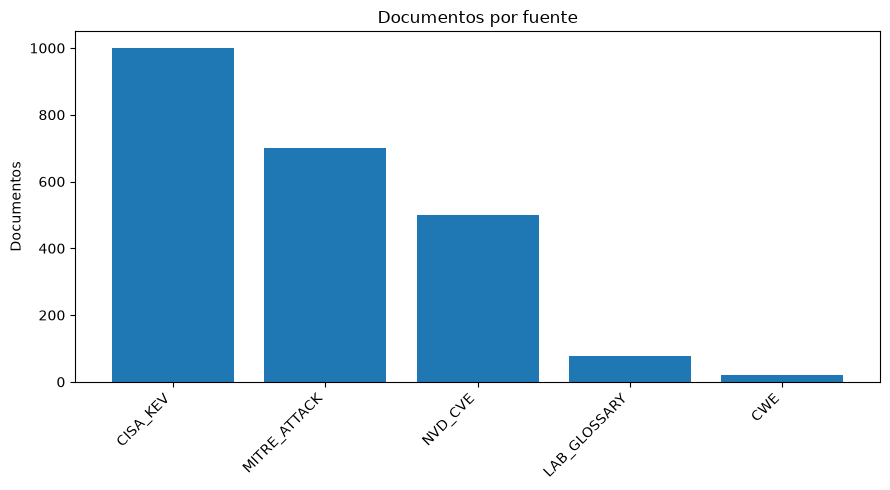

In [ ]:
counts=corpus_df['source'].value_counts(); display(counts.to_frame('documentos'))
plt.figure(figsize=(9,5)); plt.bar(counts.index,counts.values); plt.title('Documentos por fuente'); plt.ylabel('Documentos'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()

n_chars                              n_words_raw                 \
               count     mean  median   min   max       count    mean median   
source                                                                         
CISA_KEV        1000   556.86   525.0   296  1446        1000   72.33   67.0   
CWE               22  4074.82  3918.5  2629  6387          22  607.36  575.5   
LAB_GLOSSARY      78   115.08   109.0    95   149          78   14.00   14.0   
MITRE_ATTACK     700  1264.47  1124.0   147  4197         700  181.62  162.0   
NVD_CVE          500   514.99   465.5   177  3526         500   72.94   65.0   

                         
              min   max  
source                   
CISA_KEV       36   201  
CWE           364  1004  
LAB_GLOSSARY   10    18  
MITRE_ATTACK   18   560  
NVD_CVE        24   564

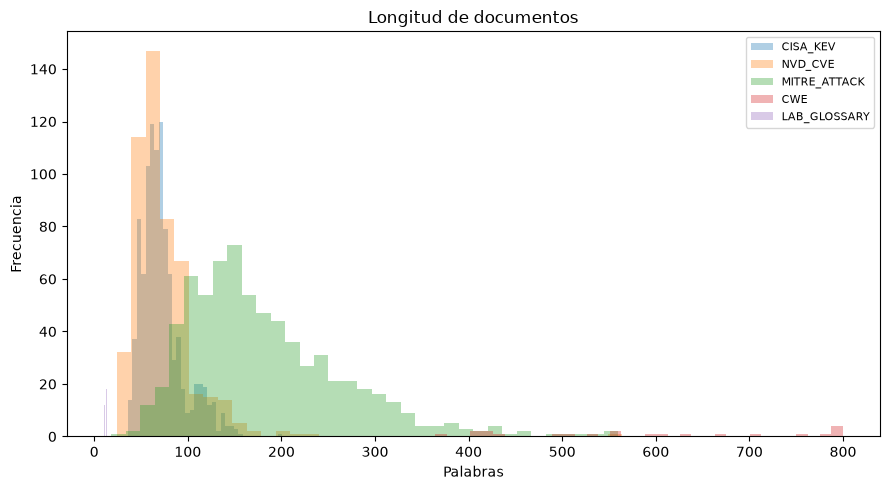

In [ ]:
display(corpus_df.groupby('source')[['n_chars','n_words_raw']].agg(['count','mean','median','min','max']).round(2))
plt.figure(figsize=(9,5))
for s in corpus_df['source'].unique():
    plt.hist(corpus_df.loc[corpus_df.source==s,'n_words_raw'].clip(upper=800),bins=35,alpha=.35,label=s)
plt.title('Longitud de documentos'); plt.xlabel('Palabras'); plt.ylabel('Frecuencia'); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. Normalización específica de ciberseguridad

No eliminamos agresivamente números y acrónimos porque podríamos destruir `CVE-...`, `CWE-...`, `T1059`, `CVSS`, etc. Convertimos identificadores a tokens estables y unimos expresiones técnicas frecuentes.

### Explicación detallada del Paso 6: Usar Sentence-BERT para comparar Frases/Documentos y Mini-Benchmark

Este paso aborda la comparación de frases y documentos completos, una tarea crucial para aplicaciones como la búsqueda semántica y el _retrieval-augmented generation_ (RAG). Aquí es donde **Sentence-BERT** (SBERT) entra en juego, optimizado específicamente para generar embeddings que son semánticamente significativos y eficientemente comparables mediante la similitud del coseno.

**¿Qué es Sentence-BERT y por qué es importante?**

*   **Embeddings de Oraciones Coherentes:** Mientras que BERT es excelente para obtener embeddings contextuales de palabras, el uso directo de BERT para obtener embeddings de oraciones (por ejemplo, promediando los embeddings de tokens) no siempre produce resultados óptimos para la comparación de similitud entre oraciones. SBERT se entrena explícitamente para esta tarea, modificando la arquitectura de BERT (o modelos similares como RoBERTa o DistilBERT) con una función de pérdida que agrupa oraciones similares en el espacio vectorial y separa las disímiles.
*   **Eficiencia en Comparaciones:** SBERT genera embeddings de oraciones en un solo pase, lo que permite calcular la similitud del coseno entre millones de pares de oraciones de manera muy eficiente, una necesidad en sistemas de búsqueda y recomendación.
*   **Aplicaciones en Ciberseguridad:** Permite encontrar documentos de CVE, KEV o mitigaciones de ATT&CK que son semánticamente similares a una consulta dada (por ejemplo, la descripción de un hallazgo de escáner de vulnerabilidades), facilitando el contexto para los analistas.

**El Mini-Benchmark:**

Para evaluar de forma didáctica la capacidad de los modelos (Word2Vec CBOW, Word2Vec Skip-Gram, FastText, BERT y Sentence-BERT) para capturar relaciones semánticas, se introduce un **mini-benchmark**. Este no es un benchmark oficial o exhaustivo, sino una herramienta para demostrar conceptualmente las fortalezas de cada modelo.

*   **Pares Relacionados vs. No Relacionados:** Consiste en una lista de pares de frases o términos que son semánticamente relacionados y otra lista de pares que no lo son. Para cada modelo, se calcula la similitud del coseno para cada par de frases.
*   **Métrica de Separación:** La métrica clave del benchmark es la "separación": la similitud promedio de los pares relacionados menos la similitud promedio de los pares no relacionados. Un valor de separación más alto indica que el modelo es mejor distinguiendo entre conceptos afines y dispares.
*   **Interpretación:** Se espera que modelos más sofisticados y contextuales como Sentence-BERT muestren una mayor separación, demostrando su superioridad en la comprensión de la relación semántica entre oraciones.

In [ ]:
SEED=42
CVE_RE=re.compile(r'\bCVE-\d{4}-\d{4,}\b',re.I); CWE_RE=re.compile(r'\bCWE-\d+\b',re.I); ATTACK_RE=re.compile(r'\bT\d{4}(?:\.\d{3})?\b',re.I)

def normalize(text):
    text=str(text).lower(); text=CVE_RE.sub(' cve_identifier ',text); text=CWE_RE.sub(' cwe_identifier ',text); text=ATTACK_RE.sub(' attack_technique_identifier ',text)
    reps={'remote code execution':'remote_code_execution','arbitrary code execution':'arbitrary_code_execution','privilege escalation':'privilege_escalation','credential dumping':'credential_dumping','known exploited vulnerabilities':'known_exploited_vulnerabilities','known exploited vulnerability':'known_exploited_vulnerability','denial of service':'denial_of_service','cross site scripting':'cross_site_scripting','sql injection':'sql_injection'}
    for a,b in reps.items(): text=text.replace(a,b)
    text=re.sub(r'https?://\S+',' url ',text); text=re.sub(r'[^a-z0-9_+\-.]+',' ',text); return re.sub(r'\s+',' ',text).strip()

def tokenize(text): return [t for t in normalize(text).split() if len(t)>=2]
corpus_df['text_norm']=corpus_df['text'].apply(normalize); corpus_df['tokens']=corpus_df['text'].apply(tokenize); corpus_df['n_tokens']=corpus_df['tokens'].str.len()
display(corpus_df[['source','doc_id','text_norm']].sample(min(6,len(corpus_df)),random_state=SEED))

,source,doc_id,text_norm
741,CISA_KEV,CVE-2023-32435,kev known_exploited_vulnerability cve_identifi...
1917,MITRE_ATTACK,T1102,mitre attack technique attack_technique_identi...
208,CISA_KEV,CVE-2025-8110,kev known_exploited_vulnerability cve_identifi...
1546,MITRE_ATTACK,T1205.002,mitre attack technique attack_technique_identi...
282,CISA_KEV,CVE-2025-38352,kev known_exploited_vulnerability cve_identifi...
479,CISA_KEV,CVE-2024-0012,kev known_exploited_vulnerability cve_identifi...


Tokens totales: 244396 | vocabulario bruto: 12708


,token,frecuencia
0,the,8254
1,to,7589
2,and,4641
3,of,3866
4,or,3848
5,may,3122
6,in,3036
7,use,2604
8,for,2559
9,an,2490


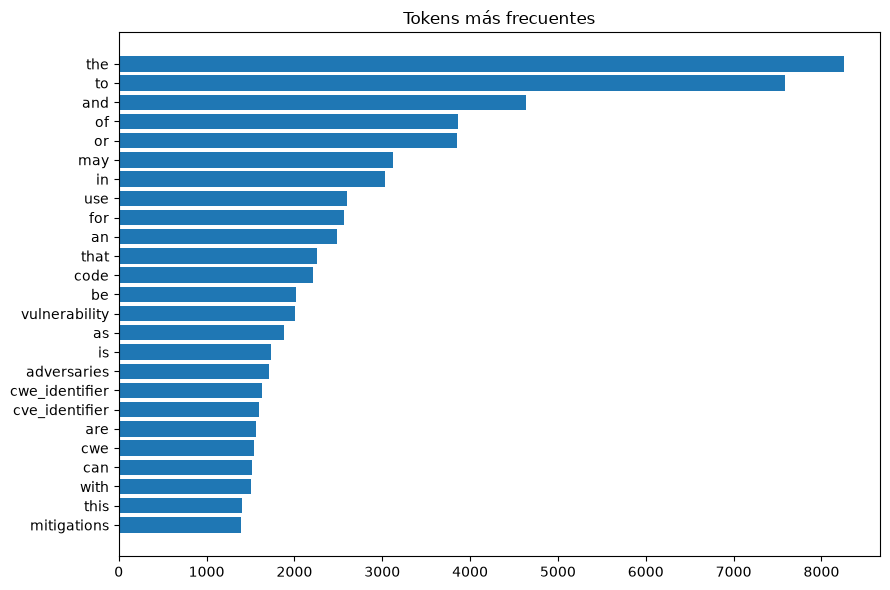

In [ ]:
counter=Counter(); [counter.update(toks) for toks in corpus_df['tokens']]
print('Tokens totales:',sum(counter.values()),'| vocabulario bruto:',len(counter))
top=pd.DataFrame(counter.most_common(25),columns=['token','frecuencia']); display(top)
plt.figure(figsize=(9,6)); p=top.sort_values('frecuencia'); plt.barh(p.token,p.frecuencia); plt.title('Tokens más frecuentes'); plt.tight_layout(); plt.show()

In [ ]:
vec=CountVectorizer(tokenizer=lambda x:x,preprocessor=None,token_pattern=None,ngram_range=(2,2),min_df=2,max_features=25, lowercase=False)
X=vec.fit_transform(corpus_df['tokens']); freq=np.asarray(X.sum(axis=0)).ravel()
display(pd.DataFrame({'bigram':vec.get_feature_names_out(),'frecuencia':freq}).sort_values('frecuencia',ascending=False).head(20))

,bigram,frecuencia
4,cwe cwe_identifier,1412
13,of the,1382
1,adversaries may,1350
9,known ransomware,1006
3,campaign use,1006
17,ransomware campaign,1006
10,known_exploited_vulnerability cve_identifier,1000
8,kev known_exploited_vulnerability,1000
18,remediation action,1000
19,required remediation,1000


## 7. Word2Vec: CBOW vs Skip-Gram

- **CBOW:** usa el contexto para predecir la palabra central.
- **Skip-Gram:** usa la palabra central para predecir palabras cercanas.

En clase puede resumirse como: **CBOW aprende “qué palabra falta”; Skip-Gram aprende “qué palabras rodean a esta”.**

In [ ]:
sentences=[x for x in corpus_df['tokens'] if len(x)>=3]
PARAMS=dict(vector_size=100,window=5,min_count=2,workers=2,negative=10,epochs=20,seed=SEED)
w2v_cbow=Word2Vec(sentences=sentences,sg=0,**PARAMS)
w2v_sg=Word2Vec(sentences=sentences,sg=1,**PARAMS)
print('Vocab CBOW:',len(w2v_cbow.wv),'| Skip-Gram:',len(w2v_sg.wv))

Vocab CBOW: 7194 | Skip-Gram: 7194


In [ ]:
TARGET=['vulnerability','exploit','ransomware','credential','privilege','patch','remediation','cvss','epss','kev','remote_code_execution']
def neighbors(model,terms,topn=6):
    rows=[]
    for t in terms:
        if t not in model.wv: rows.append({'term':t,'neighbor':'<OOV>','similarity':np.nan}); continue
        for n,s in model.wv.most_similar(t,topn=topn): rows.append({'term':t,'neighbor':n,'similarity':s})
    return pd.DataFrame(rows)
print('CBOW'); display(neighbors(w2v_cbow,TARGET))
print('SKIP-GRAM'); display(neighbors(w2v_sg,TARGET))

CBOW


,term,neighbor,similarity
0,vulnerability,flaw,0.637395
1,vulnerability,unauthenticated,0.518019
2,vulnerability,vulnerability.,0.502300
3,vulnerability,issue,0.490981
4,vulnerability,charger,0.469611
...,...,...,...
61,remote_code_execution,unspecified,0.701009
62,remote_code_execution,use-after-free,0.665608
63,remote_code_execution,sql_injection,0.646422
64,remote_code_execution,vectors..,0.609717


SKIP-GRAM


,term,neighbor,similarity
0,vulnerability,4.0,0.638519
1,vulnerability,conflict,0.624857
2,vulnerability,4hana,0.618944
3,vulnerability,1.4.2,0.612141
4,vulnerability,lms,0.608125
...,...,...,...
61,remote_code_execution,parseexcel,0.631338
62,remote_code_execution,marimo,0.623079
63,remote_code_execution,glpi,0.606771
64,remote_code_execution,unspecified,0.597164


### Interpretación

Una palabra cercana no es necesariamente sinónimo. Word2Vec aprende **coocurrencia contextual**. Por ejemplo, `patch` puede quedar cerca de `remediation`, `update`, `vendor` o `apply` porque esos términos comparten contextos.

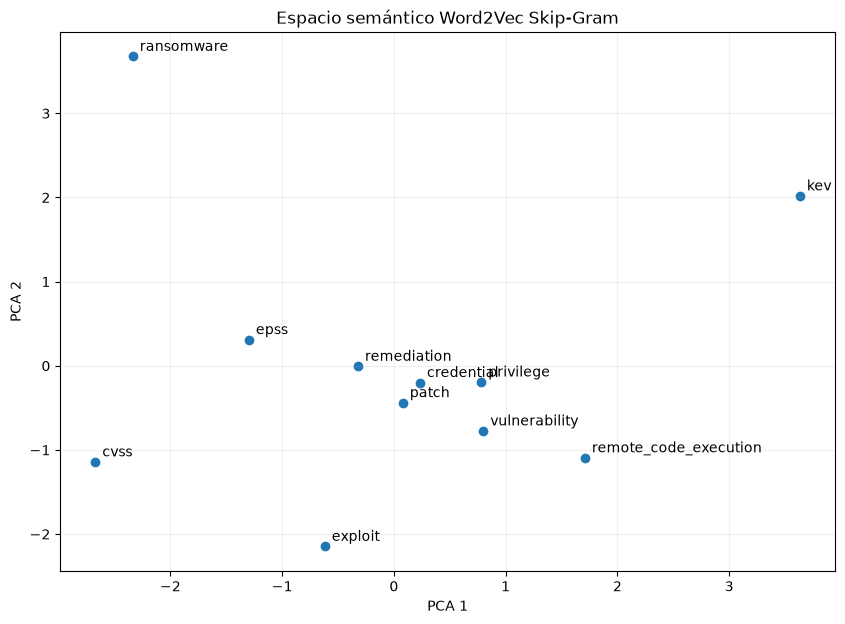

In [ ]:
def plot_space(model,terms,title):
    valid=[t for t in terms if t in model.wv]
    if len(valid)<3: return
    xy=PCA(n_components=2,random_state=SEED).fit_transform(np.vstack([model.wv[t] for t in valid]))
    plt.figure(figsize=(10,7)); plt.scatter(xy[:,0],xy[:,1])
    for t,(x,y) in zip(valid,xy): plt.annotate(t,(x,y),xytext=(5,4),textcoords='offset points')
    plt.title(title); plt.xlabel('PCA 1'); plt.ylabel('PCA 2'); plt.grid(alpha=.2); plt.show()
plot_space(w2v_sg,TARGET,'Espacio semántico Word2Vec Skip-Gram')

## 8. FastText y palabras OOV

FastText representa palabras mediante subpalabras. Esto ayuda con términos raros o formas no vistas, algo común en nombres de productos y vocabulario técnico.

In [ ]:
ft=FastText(sentences=sentences,vector_size=100,window=5,min_count=2,workers=2,sg=1,min_n=3,max_n=6,epochs=20,seed=SEED)
oov=['ransomware_variant','credentialstealing','remediationplan','vulnerabilityscanner']
display(pd.DataFrame([{'term':t,'Word2Vec_tiene_vector':t in w2v_sg.wv,'FastText_vector_norm':float(np.linalg.norm(ft.wv[t]))} for t in oov]))

,term,Word2Vec_tiene_vector,FastText_vector_norm
0,ransomware_variant,False,3.526420
1,credentialstealing,False,3.178286
2,remediationplan,False,3.649832
3,vulnerabilityscanner,False,3.331143


## 9. BERT: contexto

Word2Vec asigna un vector fijo por palabra. **BERT cambia la representación según la frase.** Usaremos `bert-base-uncased` y *mean pooling* para mantener la explicación simple.

In [ ]:
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
BERT_NAME='bert-base-uncased'; tok=AutoTokenizer.from_pretrained(BERT_NAME); bert=AutoModel.from_pretrained(BERT_NAME).to(DEVICE); bert.eval()
@torch.no_grad()
def bert_embed(texts,batch_size=16):
    if isinstance(texts,str): texts=[texts]
    out=[]
    for i in range(0,len(texts),batch_size):
        enc=tok(texts[i:i+batch_size],padding=True,truncation=True,max_length=256,return_tensors='pt'); enc={k:v.to(DEVICE) for k,v in enc.items()}
        h=bert(**enc).last_hidden_state; mask=enc['attention_mask'].unsqueeze(-1); pooled=(h*mask).sum(1)/mask.sum(1).clamp(min=1); out.append(pooled.cpu().numpy())
    return np.vstack(out)
print('BERT listo:',BERT_NAME)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT listo: bert-base-uncased


## 10. Sentence-BERT: frases y documentos

Sentence-BERT está optimizado para producir embeddings que se comparan eficientemente por similitud coseno. Es el candidato natural para **búsqueda semántica**.

In [ ]:
SBERT_NAME='sentence-transformers/all-MiniLM-L6-v2'; sbert=SentenceTransformer(SBERT_NAME,device=DEVICE); print('Sentence-BERT listo:',SBERT_NAME)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence-BERT listo: sentence-transformers/all-MiniLM-L6-v2


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.759,0.505,0.320,0.235,0.458,0.493,0.258,0.343,0.178
1,0.759,1.000,0.249,0.180,0.053,0.173,0.174,0.164,0.021,0.102
2,0.505,0.249,1.000,0.664,0.290,0.475,0.543,0.256,0.429,0.245
3,0.320,0.180,0.664,1.000,0.331,0.275,0.360,0.288,0.219,0.236
4,0.235,0.053,0.290,0.331,1.000,0.202,0.276,0.297,0.159,0.159
5,0.458,0.173,0.475,0.275,0.202,1.000,0.695,0.221,0.413,0.173
6,0.493,0.174,0.543,0.360,0.276,0.695,1.000,0.293,0.389,0.199
7,0.258,0.164,0.256,0.288,0.297,0.221,0.293,1.000,0.105,0.216
8,0.343,0.021,0.429,0.219,0.159,0.413,0.389,0.105,1.000,0.199
9,0.178,0.102,0.245,0.236,0.159,0.173,0.199,0.216,0.199,1.000


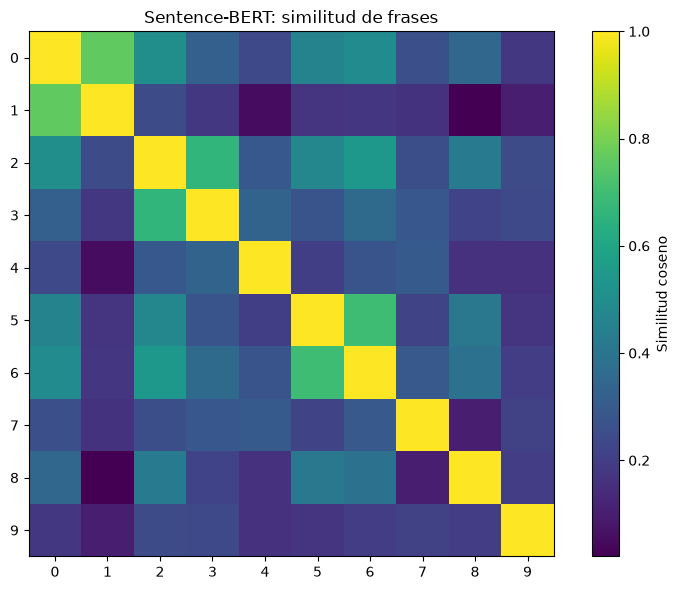

0 -> remote code execution vulnerability
1 -> arbitrary code execution on a remote server
2 -> privilege escalation vulnerability
3 -> attacker obtains elevated privileges
4 -> credential theft and credential dumping
5 -> security patch and vulnerability remediation
6 -> known exploited vulnerability requiring urgent remediation
7 -> ransomware and malicious software activity
8 -> CVSS vulnerability severity score
9 -> EPSS exploitation probability


In [ ]:
PHRASES=['remote code execution vulnerability','arbitrary code execution on a remote server','privilege escalation vulnerability','attacker obtains elevated privileges','credential theft and credential dumping','security patch and vulnerability remediation','known exploited vulnerability requiring urgent remediation','ransomware and malicious software activity','CVSS vulnerability severity score','EPSS exploitation probability']
sv=sbert.encode(PHRASES,normalize_embeddings=True,show_progress_bar=False); sm=cosine_similarity(sv)
display(pd.DataFrame(sm,index=range(len(PHRASES)),columns=range(len(PHRASES))).round(3))
plt.figure(figsize=(8,6)); plt.imshow(sm); plt.colorbar(label='Similitud coseno'); plt.title('Sentence-BERT: similitud de frases'); plt.xticks(range(len(PHRASES))); plt.yticks(range(len(PHRASES))); plt.tight_layout(); plt.show()
for i,p in enumerate(PHRASES): print(i,'->',p)

## 11. Mini-benchmark: comparar los cinco enfoques

No es un benchmark oficial. Es una prueba didáctica: los modelos deberían dar mayor similitud a pares relacionados que a pares no relacionados.

In [ ]:
RELATED=[('remote code execution vulnerability','arbitrary code execution on a remote system'),('privilege escalation','attacker obtains elevated privileges'),('credential theft','credential dumping'),('security patch','vulnerability remediation'),('known exploited vulnerability','active exploitation requiring urgent remediation'),('ransomware activity','malicious software campaign'),('CVSS severity','vulnerability severity score'),('EPSS score','probability of vulnerability exploitation')]
UNRELATED=[('remote code execution vulnerability','password rotation policy'),('privilege escalation','software inventory report'),('credential theft','network latency measurement'),('security patch','employee meeting calendar'),('ransomware activity','database performance tuning'),('CVSS severity','printer configuration'),('EPSS score','backup storage capacity'),('known exploited vulnerability','office document formatting')]

def mean_wv(text,kv):
    vs=[kv[t] for t in tokenize(text) if t in kv]; return np.mean(vs,axis=0) if vs else np.zeros(kv.vector_size)
def mean_ft(text):
    ts=tokenize(text); return np.mean([ft.wv[t] for t in ts],axis=0) if ts else np.zeros(ft.wv.vector_size)
def cos(a,b): return float(cosine_similarity(np.asarray(a).reshape(1,-1),np.asarray(b).reshape(1,-1))[0,0])

all_texts=sorted(set([x for p in RELATED+UNRELATED for x in p])); bv=bert_embed(all_texts); sv=sbert.encode(all_texts,normalize_embeddings=True,show_progress_bar=False); B=dict(zip(all_texts,bv)); S=dict(zip(all_texts,sv))

def score(model,a,b):
    if model=='Word2Vec CBOW': return cos(mean_wv(a,w2v_cbow.wv),mean_wv(b,w2v_cbow.wv))
    if model=='Word2Vec Skip-Gram': return cos(mean_wv(a,w2v_sg.wv),mean_wv(b,w2v_sg.wv))
    if model=='FastText': return cos(mean_ft(a),mean_ft(b))
    if model=='BERT': return cos(B[a],B[b])
    return cos(S[a],S[b])

models=['Word2Vec CBOW','Word2Vec Skip-Gram','FastText','BERT','Sentence-BERT']; rows=[]
for m in models:
    r=np.mean([score(m,a,b) for a,b in RELATED]); u=np.mean([score(m,a,b) for a,b in UNRELATED]); rows.append({'modelo':m,'sim_relacionados':r,'sim_no_relacionados':u,'separacion':r-u})
benchmark_df=pd.DataFrame(rows).sort_values('separacion',ascending=False); display(benchmark_df.style.format({'sim_relacionados':'{:.4f}','sim_no_relacionados':'{:.4f}','separacion':'{:.4f}'}))

,modelo,sim_relacionados,sim_no_relacionados,separacion
4,Sentence-BERT,0.5441,0.0150,0.5291
1,Word2Vec Skip-Gram,0.5680,0.2765,0.2915
2,FastText,0.6163,0.3479,0.2684
0,Word2Vec CBOW,0.2984,0.0542,0.2441
3,BERT,0.7282,0.6519,0.0763


In [ ]:
p=benchmark_df.sort_values('separacion'); plt.figure(figsize=(9,5)); plt.barh(p.modelo,p.separacion); plt.xlabel('Separación semántica'); plt.title('Pares relacionados vs no relacionados'); plt.tight_layout(); plt.show()

## 12. Comparación conceptual

In [ ]:
comparison=pd.DataFrame([
['Word2Vec CBOW','palabra','No','No','Sí','simple y rápido','glosario/relaciones'],
['Word2Vec Skip-Gram','palabra','No','No','Sí','términos menos frecuentes','vocabulario técnico'],
['FastText','palabra/subpalabra','No','Mejor','Sí','OOV y variantes','productos/términos raros'],
['BERT','token/frase','Sí','Subwords','No, preentrenado','contexto','clasificación/enriquecimiento'],
['Sentence-BERT','frase/documento','Sí','Subwords','No, preentrenado','similitud documental','retrieval/RAG']
],columns=['modelo','unidad','contextual','OOV','entrenamos_aqui','fortaleza','uso_EMCALI'])
display(comparison)

,modelo,unidad,contextual,OOV,entrenamos_aqui,fortaleza,uso_EMCALI
0,Word2Vec CBOW,palabra,No,No,Sí,simple y rápido,glosario/relaciones
1,Word2Vec Skip-Gram,palabra,No,No,Sí,términos menos frecuentes,vocabulario técnico
2,FastText,palabra/subpalabra,No,Mejor,Sí,OOV y variantes,productos/términos raros
3,BERT,token/frase,Sí,Subwords,"No, preentrenado",contexto,clasificación/enriquecimiento
4,Sentence-BERT,frase/documento,Sí,Subwords,"No, preentrenado",similitud documental,retrieval/RAG


## 13. Aplicación: `Semantic_Vuln_Intelligence` para EMCALI Cyber 2.0

Arquitectura conceptual:

```text
Tenable / Qualys / OpenVAS / NVD / KEV
                 ↓
          Normalización JSON
                 ↓
          Sentence-BERT
                 ↓
       FAISS / Chroma / pgvector
                 ↓
      Top-K CVE / KEV / CWE / docs
                 ↓
        Contexto para analista/RAG
```

Los embeddings **no reemplazan** CVSS, EPSS, KEV, criticidad del activo, exposición ni juicio del analista. Su papel es recuperar contexto relevante.

### Integración de los Resultados en un Sistema RAG Sencillo

Los resultados de este laboratorio, particularmente los embeddings generados por **Sentence-BERT** y la funcionalidad de búsqueda semántica, son la base para construir un sistema de *Retrieval-Augmented Generation* (RAG) sencillo. Un sistema RAG combina la capacidad de un modelo de lenguaje grande (LLM) para generar texto coherente con la precisión de un sistema de recuperación de información.

Aquí se describe cómo se integraría:

1.  **Indexación de Documentos (Creación de la Base de Conocimiento):**
    *   **Embeddings:** Se utilizan los mismos embeddings de Sentence-BERT que ya generamos para nuestro `retrieval_df` (CVEs, KEVs, CWEs). Cada documento (descripción de vulnerabilidad, mitigación, etc.) se convierte en un vector numérico.
    *   **Base de Datos Vectorial:** Estos vectores se almacenan en una base de datos vectorial eficiente (como FAISS, ChromaDB, Pinecone, o incluso PostgreSQL con `pgvector`). Esta base de datos permite realizar búsquedas de similitud (vecinos más cercanos) de manera muy rápida.

2.  **Consulta del Usuario y Recuperación (Retrieval):**
    *   Cuando un usuario hace una pregunta o proporciona una descripción (ej., "¿Qué CVEs están relacionadas con la vulnerabilidad de ejecución remota de código en Apache Struts?"), esta consulta se convierte en un vector utilizando el mismo modelo Sentence-BERT.
    *   Este vector de consulta se usa para buscar en la base de datos vectorial y recuperar los `k` documentos más relevantes (CVEs, KEVs, etc.) que son semánticamente similares a la consulta del usuario. Esta es la funcionalidad `semantic_search` que hemos desarrollado.

3.  **Generación Aumentada (Augmented Generation):**
    *   Los documentos recuperados en el paso anterior no se muestran directamente al usuario. En su lugar, se pasan como **contexto** a un Modelo de Lenguaje Grande (LLM) (ej., Gemini, LLaMA, GPT, Mistral).
    *   El prompt para el LLM se construye de la siguiente manera:

        ```
        "Basado en la siguiente información de contexto, responde a la pregunta del usuario de la manera más precisa posible:

        Contexto:
        [Documento 1 recuperado]
        [Documento 2 recuperado]
        ...
        [Documento N recuperado]

        Pregunta del usuario: [Consulta original del usuario]"
        ```
    *   El LLM utiliza este contexto para formular una respuesta más informada, precisa y relevante, en lugar de depender únicamente de su conocimiento pre-entrenado, que podría estar desactualizado o ser genérico.

**Beneficios Clave:**

*   **Actualidad:** El sistema puede responder preguntas sobre información muy reciente (nuevas CVEs, KEVs) siempre que la base de datos vectorial se actualice regularmente.
*   **Reducción de Alucinaciones:** Al proporcionar contexto específico, se reduce la tendencia de los LLM a "inventar" información.
*   **Precisión y Relevancia:** Las respuestas son más directamente relevantes a las fuentes de datos de ciberseguridad.

**Ejemplo en EMCALI Cyber 2.0:**

Un analista podría preguntar al sistema RAG: "¿Cuáles son las mitigaciones recomendadas para la vulnerabilidad CVE-2023-XXXX con un EPSS alto?". El sistema recuperaría el CVE, KEVs relacionados, y mitigaciones de ATT&CK, y luego un LLM generaría una respuesta consolidada y accionable basada en esa información.

### Esquema de los pasos para conectar los embeddings de SBERT con una Base de Datos Vectorial

Conectar los embeddings generados por Sentence-BERT (SBERT) con una base de datos vectorial es un componente clave para implementar la búsqueda semántica y los sistemas RAG. Aquí se detalla el proceso en varios pasos:

1.  **Obtener los Documentos Originales:**
    *   Recopilar todos los documentos (o fragmentos de texto) que se desean indexar. Esto puede incluir descripciones de CVE, KEV, CWE, mitigaciones de ATT&CK, documentación interna, etc.
    *   Cada documento debe tener un identificador único (`doc_id`) y el texto asociado.

2.  **Preprocesamiento de los Documentos:**
    *   Aplicar las mismas técnicas de limpieza y normalización utilizadas en el Paso 2 (Limpieza del Texto sin destruir CVE/CWE/acrónimos) para asegurar que el texto sea consistente con el que el modelo SBERT fue entrenado o fine-tuned.

3.  **Generación de Embeddings con SBERT:**
    *   Utilizar el modelo SBERT (`SentenceTransformer`) para codificar cada documento preprocesado en un vector numérico (embedding).
    *   Es importante asegurar que los embeddings estén normalizados (por ejemplo, `normalize_embeddings=True` en `sbert.encode`) para que la similitud coseno sea una medida de distancia efectiva.
    *   Ejemplo de código (como ya se ha visto):
        ```python
        from sentence_transformers import SentenceTransformer
        sbert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
        document_texts = [doc['text_normalized'] for doc in documents]
        document_embeddings = sbert_model.encode(document_texts, normalize_embeddings=True, show_progress_bar=True)
        ```

4.  **Almacenamiento en la Base de Datos Vectorial:**
    *   Seleccionar una base de datos vectorial (ej. FAISS para pruebas locales y rendimiento, ChromaDB para facilidad de uso, Pinecone/Weaviate para escala en la nube, o pgvector para PostgreSQL).
    *   Para cada documento, almacenar el `doc_id` original, el texto original (opcionalmente) y su embedding correspondiente en la base de datos vectorial.
    *   La base de datos se encargará de indexar estos vectores de manera eficiente para búsquedas rápidas de similitud de vecinos más cercanos.

5.  **Procesamiento de Consultas (Query Processing):**
    *   Cuando un usuario envía una consulta de texto, esta se preprocesa de la misma manera que los documentos originales.
    *   La consulta preprocesada se codifica utilizando **el mismo modelo SBERT** que se usó para generar los embeddings de los documentos. Esto asegura que la consulta y los documentos estén en el mismo espacio vectorial.
    *   Ejemplo:
        ```python
        query_text = "vulnerabilidad de ejecución remota de código en servicios web"
        query_embedding = sbert_model.encode([query_text], normalize_embeddings=True)[0]
        ```

6.  **Búsqueda de Similitud (Retrieval):**
    *   La base de datos vectorial recibe el embedding de la consulta.
    *   Realiza una búsqueda de similitud (usando similitud coseno, distancia euclidiana, etc.) para encontrar los `k` embeddings de documentos más cercanos al embedding de la consulta.
    *   La base de datos devuelve los `doc_id` de los documentos más relevantes, junto con sus puntuaciones de similitud.

7.  **Recuperación de Contenido Original:**
    *   Usando los `doc_id` recuperados de la base de datos vectorial, se accede a la fuente original o a un almacenamiento de documentos (como el `retrieval_df` en nuestro caso) para obtener el texto completo y los metadatos de los documentos relevantes.

8.  **Uso del Contenido Recuperado:**
    *   El texto de los documentos recuperados se puede presentar directamente al usuario.
    *   O, como en un sistema RAG, se puede pasar como contexto a un LLM para generar una respuesta más elaborada y contextualizada, como se explicó en el paso anterior.

In [ ]:
retrieval_df=corpus_df[corpus_df.source.isin(['NVD_CVE','CISA_KEV','CWE'])].copy().reset_index(drop=True)
if len(retrieval_df)>2200: retrieval_df=retrieval_df.sample(2200,random_state=SEED).reset_index(drop=True)
retrieval_embeddings=sbert.encode(retrieval_df.text.tolist(),batch_size=64 if torch.cuda.is_available() else 16,normalize_embeddings=True,show_progress_bar=True)
print('Índice semántico:',retrieval_embeddings.shape)

def semantic_search(query,top_k=10):
    q=sbert.encode([query],normalize_embeddings=True,show_progress_bar=False); scores=cosine_similarity(q,retrieval_embeddings)[0]; idx=np.argsort(scores)[::-1][:top_k]
    out=retrieval_df.loc[idx,['source','doc_id','title','text']].copy(); out['semantic_score']=scores[idx]; return out.reset_index(drop=True)

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Índice semántico: (1522, 384)


In [ ]:
query='remote code execution vulnerability in a network-facing service requiring urgent patching and remediation'
print('CONSULTA:',query); display(semantic_search(query,10))

CONSULTA: remote code execution vulnerability in a network-facing service requiring urgent patching and remediation


,source,doc_id,title,text,semantic_score
0,CISA_KEV,CVE-2015-1671,Microsoft Windows Remote Code Execution Vulner...,KEV known exploited vulnerability CVE-2015-167...,0.653533
1,CISA_KEV,CVE-2022-30190,Microsoft Windows Support Diagnostic Tool (MSD...,KEV known exploited vulnerability CVE-2022-301...,0.619324
2,CISA_KEV,CVE-2014-4148,Microsoft Windows Remote Code Execution Vulner...,KEV known exploited vulnerability CVE-2014-414...,0.610479
3,CISA_KEV,CVE-2022-34713,Microsoft Windows Support Diagnostic Tool (MSD...,KEV known exploited vulnerability CVE-2022-347...,0.594375
4,CISA_KEV,CVE-2019-1068,Microsoft SQL Server Remote Code Execution Vul...,KEV known exploited vulnerability CVE-2019-106...,0.590369
5,CISA_KEV,CVE-2026-1731,BeyondTrust Remote Support (RS) and Privileged...,KEV known exploited vulnerability CVE-2026-173...,0.584898
6,CISA_KEV,CVE-2024-38189,Microsoft Project Remote Code Execution Vulner...,KEV known exploited vulnerability CVE-2024-381...,0.579383
7,CISA_KEV,CVE-2024-43572,Microsoft Windows Management Console Remote Co...,KEV known exploited vulnerability CVE-2024-435...,0.566100
8,CISA_KEV,CVE-2023-24955,Microsoft SharePoint Server Code Injection Vul...,KEV known exploited vulnerability CVE-2023-249...,0.564648
9,CISA_KEV,CVE-2010-2568,Microsoft Windows Remote Code Execution Vulner...,KEV known exploited vulnerability CVE-2010-256...,0.563133


In [ ]:
query='privilege escalation involving stolen credentials and unauthorized elevated access'
print('CONSULTA:',query); display(semantic_search(query,10))

CONSULTA: privilege escalation involving stolen credentials and unauthorized elevated access


,source,doc_id,title,text,semantic_score
0,NVD_CVE,CVE-2025-9973,CVE-2025-9973,CVE vulnerability CVE-2025-9973. Due to not va...,0.498213
1,CISA_KEV,CVE-2022-26923,Microsoft Active Directory Domain Services Pri...,KEV known exploited vulnerability CVE-2022-269...,0.493311
2,CISA_KEV,CVE-2023-29357,Microsoft SharePoint Server Privilege Escalati...,KEV known exploited vulnerability CVE-2023-293...,0.432339
3,CISA_KEV,CVE-2024-49039,Microsoft Windows Task Scheduler Privilege Esc...,KEV known exploited vulnerability CVE-2024-490...,0.427544
4,CISA_KEV,CVE-2026-21533,Microsoft Windows Improper Privilege Managemen...,KEV known exploited vulnerability CVE-2026-215...,0.420052
5,CISA_KEV,CVE-2015-1769,Microsoft Windows Mount Manager Privilege Esca...,KEV known exploited vulnerability CVE-2015-176...,0.418620
6,NVD_CVE,CVE-2025-10908,CVE-2025-10908,CVE vulnerability CVE-2025-10908. Due to a lac...,0.417104
7,CISA_KEV,CVE-2024-38080,Microsoft Windows Hyper-V Privilege Escalation...,KEV known exploited vulnerability CVE-2024-380...,0.415603
8,CISA_KEV,CVE-2021-3560,Red Hat Polkit Incorrect Authorization Vulnera...,KEV known exploited vulnerability CVE-2021-356...,0.414240
9,CISA_KEV,CVE-2024-8068,Citrix Session Recording Improper Privilege Ma...,KEV known exploited vulnerability CVE-2024-806...,0.413541


In [ ]:
query='known exploited vulnerability associated with ransomware that should receive high remediation attention'
print('CONSULTA:',query); display(semantic_search(query,10))

CONSULTA: known exploited vulnerability associated with ransomware that should receive high remediation attention


,source,doc_id,title,text,semantic_score
0,CISA_KEV,CVE-2024-12686,BeyondTrust Privileged Remote Access (PRA) and...,KEV known exploited vulnerability CVE-2024-126...,0.648967
1,CISA_KEV,CVE-2023-34192,Synacor Zimbra Collaboration Suite (ZCS) Cross...,KEV known exploited vulnerability CVE-2023-341...,0.617993
2,CISA_KEV,CVE-2026-45247,Mirasvit Full Page Cache Warmer Deserializatio...,KEV known exploited vulnerability CVE-2026-452...,0.611995
3,CISA_KEV,CVE-2023-41179,Trend Micro Apex One and Worry-Free Business S...,KEV known exploited vulnerability CVE-2023-411...,0.609201
4,CISA_KEV,CVE-2010-3962,Microsoft Internet Explorer Uninitialized Memo...,KEV known exploited vulnerability CVE-2010-396...,0.607335
5,CISA_KEV,CVE-2024-42009,RoundCube Webmail Cross-Site Scripting Vulnera...,KEV known exploited vulnerability CVE-2024-420...,0.596756
6,CISA_KEV,CVE-2025-22226,"VMware ESXi, Workstation, and Fusion Informati...",KEV known exploited vulnerability CVE-2025-222...,0.594338
7,CISA_KEV,CVE-2024-38475,Apache HTTP Server Improper Escaping of Output...,KEV known exploited vulnerability CVE-2024-384...,0.593942
8,CISA_KEV,CVE-2021-32030,ASUS Routers Improper Authentication Vulnerabi...,KEV known exploited vulnerability CVE-2021-320...,0.592276
9,CISA_KEV,CVE-2026-22769,Dell RecoverPoint for Virtual Machines (RP4VMs...,KEV known exploited vulnerability CVE-2026-227...,0.591965


### Demo tipo hallazgo de escáner

La entrada puede ser una descripción normalizada procedente de Tenable, Qualys, Nessus/OpenVAS u otra fuente. El sistema no ejecuta nada; sólo busca conocimiento relacionado.

In [ ]:
scanner_finding='The scanner reports a critical vulnerability in a web-facing service. The weakness may allow remote arbitrary code execution without normal user interaction. The security team should identify the vendor fix, apply the recommended patch and verify remediation.'
display(semantic_search(scanner_finding,8))

,source,doc_id,title,text,semantic_score
0,CISA_KEV,CVE-2022-30190,Microsoft Windows Support Diagnostic Tool (MSD...,KEV known exploited vulnerability CVE-2022-301...,0.554718
1,CISA_KEV,CVE-2015-1671,Microsoft Windows Remote Code Execution Vulner...,KEV known exploited vulnerability CVE-2015-167...,0.545360
2,CISA_KEV,CVE-2020-14644,Oracle WebLogic Server Remote Code Execution V...,KEV known exploited vulnerability CVE-2020-146...,0.542467
3,CISA_KEV,CVE-2024-56145,Craft CMS Code Injection Vulnerability,KEV known exploited vulnerability CVE-2024-561...,0.537336
4,CISA_KEV,CVE-2022-34713,Microsoft Windows Support Diagnostic Tool (MSD...,KEV known exploited vulnerability CVE-2022-347...,0.535992
5,NVD_CVE,CVE-2025-61308,CVE-2025-61308,CVE vulnerability CVE-2025-61308. A reflected ...,0.535389
6,CISA_KEV,CVE-2023-24955,Microsoft SharePoint Server Code Injection Vul...,KEV known exploited vulnerability CVE-2023-249...,0.534054
7,CISA_KEV,CVE-2024-34102,Adobe Commerce and Magento Open Source Imprope...,KEV known exploited vulnerability CVE-2024-341...,0.531022


## 14. Narrativa automática de resultados

La siguiente celda interpreta **la ejecución real**, evitando inventar de antemano qué modelo será mejor.

In [ ]:
best=benchmark_df.iloc[0]; print('HALLAZGOS'); print('='*70)
print(f"1. Mayor separación del mini-benchmark: {best['modelo']} ({best['separacion']:.4f}).")
cb=float(benchmark_df.loc[benchmark_df.modelo=='Word2Vec CBOW','separacion'].iloc[0]); sg=float(benchmark_df.loc[benchmark_df.modelo=='Word2Vec Skip-Gram','separacion'].iloc[0])
print('2. Skip-Gram superó a CBOW en esta corrida.' if sg>cb else '2. CBOW igualó o superó a Skip-Gram en esta corrida.')
print('3. FastText aporta soporte estructural para términos OOV mediante subpalabras.')
print('4. BERT añade contexto; Sentence-BERT facilita comparar frases/documentos.')
print('5. Para EMCALI Cyber 2.0, Sentence-BERT es el componente más directamente reutilizable de esta práctica para retrieval/RAG.')

HALLAZGOS
1. Mayor separación del mini-benchmark: Sentence-BERT (0.5291).
2. Skip-Gram superó a CBOW en esta corrida.
3. FastText aporta soporte estructural para términos OOV mediante subpalabras.
4. BERT añade contexto; Sentence-BERT facilita comparar frases/documentos.
5. Para EMCALI Cyber 2.0, Sentence-BERT es el componente más directamente reutilizable de esta práctica para retrieval/RAG.


### Narrativa Automática de Resultados

Esta sección interpreta automáticamente los hallazgos clave del mini-benchmark y otros componentes del laboratorio. En lugar de una conclusión manual, el sistema genera una narrativa basada en los resultados obtenidos durante la ejecución. Esto es particularmente útil en entornos donde se realizan múltiples experimentos o donde se busca una interpretación estandarizada y objetiva de los datos.

Los puntos que se destacan en esta narrativa son:

1.  **Mayor Separación del Mini-Benchmark:** Identifica qué modelo (Word2Vec CBOW, Word2Vec Skip-Gram, FastText, BERT, Sentence-BERT) ha logrado la mayor diferencia entre la similitud de pares de frases relacionadas y no relacionadas. Un valor de separación más alto indica que el modelo es más efectivo para distinguir entre conceptos afines y dispares en el dominio de ciberseguridad.

2.  **Comparación Específica CBOW vs. Skip-Gram:** Contrasta el rendimiento de las dos arquitecturas de Word2Vec para observar cuál fue más efectiva en esta ejecución particular del laboratorio. Esto ayuda a comprender las sutilezas de cada enfoque para el corpus dado.

3.  **Aporte de FastText:** Explica cómo FastText, al usar subpalabras, proporciona una ventaja estructural al poder generar vectores para términos fuera del vocabulario (OOV) o variantes, lo cual es crucial en un dominio en constante evolución como la ciberseguridad.

4.  **Rol de BERT y Sentence-BERT:** Resalta la capacidad de BERT para añadir contexto a las palabras y cómo Sentence-BERT facilita la comparación de frases y documentos completos, siendo fundamental para la búsqueda semántica y RAG.

5.  **Recomendación para EMCALI Cyber 2.0:** Concluye con una sugerencia sobre cuál de los enfoques estudiados es más directamente aplicable y reutilizable para las necesidades de EMCALI Cyber 2.0, enfatizando su potencial para sistemas de _retrieval_ y RAG.

Esta narrativa automática asegura que la interpretación de los resultados sea consistente, reproducible y basada en la evidencia generada por el propio laboratorio, facilitando la comprensión y la toma de decisiones.

### Automatización de la Generación de Reportes Basada en Hallazgos del Benchmark

La automatización de la generación de reportes a partir de los hallazgos del benchmark, como los que se interpretan en la "Narrativa Automática de Resultados", es una capacidad invaluable para equipos de ciberseguridad y analistas de datos. Permite la difusión rápida, consistente y escalable de información crítica, liberando tiempo que de otro modo se invertiría en la creación manual de reportes.

**Componentes y Proceso para la Automatización:**

1.  **Extracción de Métricas Clave:**
    *   Los resultados del benchmark (ej., `benchmark_df`) y las conclusiones de la narrativa automática son la fuente de datos. Se extraen métricas como la separación de modelos, el modelo de mejor rendimiento, las comparaciones específicas (CBOW vs. Skip-Gram), y el modelo recomendado para aplicaciones de EMCALI Cyber 2.0.
    *   Estas métricas ya están calculadas en las celdas anteriores (ej., `best` para el modelo con mayor separación).

2.  **Plantillas de Reporte:**
    *   Se diseñan plantillas de reporte utilizando formatos como Markdown, HTML, LaTeX o herramientas de BI. Estas plantillas contienen marcadores de posición donde se insertarán dinámicamente los datos extraídos.
    *   Las plantillas pueden incluir secciones para:
        *   Resumen ejecutivo.
        *   Metodología del benchmark.
        *   Resultados clave (tablas, gráficos de barras de separación).
        *   Conclusiones y recomendaciones específicas (como las generadas por la narrativa automática).
        *   Apéndices (ej., detalles de los modelos, hiperparámetros).

3.  **Motor de Renderizado:**
    *   Se utiliza un motor de renderizado (ej., Jinja2 para Python, o herramientas específicas para informes) que toma los datos extraídos y la plantilla, y genera un reporte final.
    *   Para Jupyter/Colab, se puede generar Markdown directamente, o incluso HTML/PDF si se integran librerías como `nbconvert` o `WeasyPrint`.

4.  **Inclusión de Visualizaciones:**
    *   Los gráficos generados durante el EDA y el benchmark (ej., `plot_space`, gráficos de `benchmark_df`) son fundamentales. En un reporte automatizado, estas visualizaciones pueden ser exportadas como imágenes (PNG, SVG) y luego incrustadas en el documento final.
    *   El código `plt.savefig()` es crucial aquí para guardar los gráficos de manera programática.

5.  **Ejemplo de Integración en el Notebook (Markdown):**
    *   La propia "Narrativa Automática de Resultados" ya es un paso hacia la automatización, ya que genera texto descriptivo basado en los datos. Para un reporte más formal, podríamos generar una celda de Markdown más estructurada que contenga los datos y las conclusiones:

    ```markdown
    ## Informe de Evaluación de Embeddings de Ciberseguridad

    **Fecha de Generación:** [Fecha actual]

    ### Resumen Ejecutivo
    Este informe presenta los resultados de la evaluación de diferentes modelos de embeddings (*Word2Vec CBOW, Word2Vec Skip-Gram, FastText, BERT, Sentence-BERT*) en un corpus de ciberseguridad, con énfasis en su aplicabilidad para EMCALI Cyber 2.0.

    ### Metodología
    Se empleó un mini-benchmark que compara la similitud coseno entre pares de frases relacionadas y no relacionadas. Se consideraron métricas de separación semántica.

    ### Hallazgos Clave
    El modelo con mayor separación en el mini-benchmark fue **[Modelo con mayor separación]** con un índice de **[Valor de separación]**.
    *   En esta ejecución, **[Word2Vec CBOW/Skip-Gram]** demostró ser más efectivo.
    *   **FastText** mostró su valor al manejar términos fuera de vocabulario (OOV) mediante subpalabras.
    *   **BERT** se destacó por su capacidad contextual, mientras que **Sentence-BERT** es crucial para la comparación eficiente de frases y documentos.

    ### Recomendación para EMCALI Cyber 2.0
    Se recomienda **Sentence-BERT** como el componente más directamente reutilizable para sistemas de recuperación de información y RAG, dada su optimización para la búsqueda semántica.

    ### Detalles del Benchmark
    | Modelo             | Similitud Relacionados | Similitud No Relacionados | Separación |
    |--------------------|------------------------|---------------------------|------------|
    [Tabla de benchmark_df renderizada automáticamente]

    [Gráfico de separación de modelos incrustado aquí]
    ```

**Ventajas de la Automatización:**

*   **Consistencia:** Todos los reportes siguen el mismo formato y utilizan las mismas definiciones de métricas.
*   **Eficiencia:** Reduce drásticamente el tiempo y el esfuerzo necesarios para generar reportes, especialmente cuando se requiere una alta frecuencia.
*   **Escalabilidad:** Permite generar reportes para múltiples experimentos, configuraciones o periodos sin esfuerzo adicional.
*   **Objetividad:** Elimina el sesgo humano en la selección e interpretación de los resultados.
*   **Actualidad:** Facilita la generación de reportes con los datos más recientes.

## 15. Limitaciones

1. Corpus pequeño frente a entrenamiento industrial.
2. Fuentes con estilos lingüísticos distintos.
3. El glosario controla la cobertura y altera parcialmente Word2Vec.
4. BERT/MiniLM son modelos generales, no especializados en vulnerabilidades.
5. El mini-benchmark es didáctico, no oficial.
6. PCA pierde información.
7. Similitud semántica **no equivale** a prioridad de riesgo.
8. Un entorno productivo necesita versionado, trazabilidad, gobierno del dato y evaluación de retrieval (`Recall@K`, `MRR`, `nDCG`).

## 16. Siguiente versión recomendada

Para una V2 orientada a EMCALI Cyber 2.0:
- enriquecer CVE con EPSS real;
- CVSS v3.1/v4;
- KEV y ransomware flag;
- CVE→CWE;
- CWE→CAPEC;
- ATT&CK Enterprise + ICS;
- embeddings especializados en ciberseguridad;
- FAISS/Chroma;
- RAG con Ollama/local-cloud híbrido;
- re-ranking;
- evaluación `Precision@K`, `Recall@K`, `MRR`, `nDCG`;
- integración con documentos internos autorizados.

## 17. Resumen de 60 segundos para exposición

> Construimos un corpus con NVD/CVE, CISA KEV, CWE y MITRE ATT&CK. Entrenamos Word2Vec con CBOW y Skip-Gram para observar relaciones entre palabras. Después usamos FastText para manejar palabras no vistas, BERT para incorporar contexto y Sentence-BERT para comparar frases y documentos. Finalmente convertimos descripciones de vulnerabilidades en vectores y construimos una búsqueda semántica. Ese último componente puede convertirse en un módulo de EMCALI Cyber 2.0 para recuperar CVE, KEV, CWE y documentos relevantes antes de generar recomendaciones mediante RAG o un LLM.

## 18. Exportación de resultados

In [ ]:
ART=Path('artifacts_cyber_nlp'); ART.mkdir(exist_ok=True)
corpus_df.drop(columns=['tokens'],errors='ignore').to_csv(ART/'cybersecurity_corpus.csv',index=False)
benchmark_df.to_csv(ART/'benchmark_embeddings.csv',index=False); comparison.to_csv(ART/'comparacion_modelos.csv',index=False)
w2v_cbow.save(str(ART/'word2vec_cbow.model')); w2v_sg.save(str(ART/'word2vec_skipgram.model')); ft.save(str(ART/'fasttext_cyber.model'))
config={'seed':SEED,'attack_version':ATTACK_VERSION,'nvd_days':NVD_DAYS,'bert_model':BERT_NAME,'sbert_model':SBERT_NAME,'word2vec':PARAMS}
with open(ART/'config.json','w',encoding='utf-8') as f: json.dump(config,f,ensure_ascii=False,indent=2)
print('Artefactos:'); [print('-',p) for p in sorted(ART.iterdir())]

Artefactos:
- artifacts_cyber_nlp/benchmark_embeddings.csv
- artifacts_cyber_nlp/comparacion_modelos.csv
- artifacts_cyber_nlp/config.json
- artifacts_cyber_nlp/cybersecurity_corpus.csv
- artifacts_cyber_nlp/fasttext_cyber.model
- artifacts_cyber_nlp/fasttext_cyber.model.wv.vectors_ngrams.npy
- artifacts_cyber_nlp/word2vec_cbow.model
- artifacts_cyber_nlp/word2vec_skipgram.model


[None, None, None, None, None, None, None, None]

### Explicación detallada del Paso 18: Exportación de Resultados

El paso de `Exportación de Resultados` es fundamental en cualquier proyecto de análisis de datos o machine learning. Su objetivo principal es asegurar la **reproducibilidad**, facilitar la **reutilización** de los modelos y datos, y permitir la **integración** de los hallazgos en sistemas o flujos de trabajo externos.

En esta sección, se guardan varios artefactos clave generados durante el laboratorio:

1.  **`cybersecurity_corpus.csv` (Corpus de Texto):**
    *   Este archivo CSV contiene el corpus completo de documentos de ciberseguridad, incluyendo los textos originales, los identificadores, las fuentes y los textos normalizados (`text_norm`).
    *   **Utilidad:** Es crucial para replicar el preprocesamiento de datos, para futuras extensiones del corpus o para entrenar nuevos modelos con la misma base textual.

2.  **`benchmark_embeddings.csv` (Resultados del Mini-Benchmark):**
    *   Contiene la tabla que resume el rendimiento de cada modelo (Word2Vec CBOW, Word2Vec Skip-Gram, FastText, BERT, Sentence-BERT) en el mini-benchmark, mostrando la similitud de pares relacionados, no relacionados y la métrica de separación.
    *   **Utilidad:** Permite analizar y comparar objetivamente el rendimiento de los modelos sin necesidad de volver a ejecutar todo el benchmark, y sirve como base para informes o dashboards.

3.  **`comparacion_modelos.csv` (Tabla Comparativa Conceptual):**
    *   Este CSV almacena la tabla que compara conceptualmente las características de cada modelo (unidad de procesamiento, contextualidad, manejo de OOV, etc.), así como sus fortalezas y usos recomendados para EMCALI Cyber 2.0.
    *   **Utilidad:** Es una referencia rápida para entender las diferencias teóricas y prácticas de los modelos, útil para la documentación y la toma de decisiones.

4.  **Modelos de Embeddings (Word2Vec, FastText):**
    *   Se guardan los modelos entrenados de `word2vec_cbow.model`, `word2vec_skipgram.model` y `fasttext_cyber.model`.
    *   **Utilidad:** Estos archivos contienen los pesos y vocabularios aprendidos por los modelos, lo que permite cargarlos en cualquier momento para generar nuevos embeddings, realizar análisis de similitud de palabras, o integrarlos en aplicaciones sin la necesidad de re-entrenarlos, lo cual puede ser costoso computacionalmente.

5.  **`config.json` (Configuración del Laboratorio):**
    *   Un archivo JSON que registra los parámetros clave utilizados en la ejecución del laboratorio, como la semilla de aleatoriedad (`seed`), la versión de ATT&CK, el número de días para la consulta de NVD, y los nombres de los modelos de BERT y SBERT, así como los parámetros de Word2Vec.
    *   **Utilidad:** Es esencial para la reproducibilidad de los experimentos, ya que documenta las condiciones bajo las cuales se obtuvieron los resultados.

Al exportar estos artefactos, el laboratorio se convierte en un conjunto de resultados autocontenido y reutilizable, lo que es una buena práctica en la ciencia de datos y la ingeniería de machine learning.

## 19. Estructura sugerida de GitHub

```text
cybersecurity-word2vec-laboratory/
├── notebooks/
│   └── Caso2_Cybersecurity_Word2Vec_Laboratory_EMCALI_Cyber2.ipynb
├── artifacts/
├── figures/
├── README.md
├── requirements.txt
└── .gitignore
```

`.gitignore` recomendado:

```text
.ipynb_checkpoints/
__pycache__/
*.bin
*.pt
*.ckpt
artifacts_cyber_nlp/*.model
```

## 20. Referencias principales

- NIST — National Vulnerability Database (NVD), CVE API 2.0.
- CISA — Known Exploited Vulnerabilities (KEV).
- MITRE — ATT&CK Enterprise STIX.
- MITRE — Common Weakness Enumeration (CWE) y REST API.
- Mikolov et al. — Word2Vec.
- Bojanowski et al. — FastText.
- Devlin et al. — BERT.
- Reimers & Gurevych — Sentence-BERT.
- Gensim, Hugging Face Transformers y Sentence-Transformers.